In [1]:
import pandas as pd
from os import listdir
from os.path import isfile, join

In [2]:
def get_abs(abs_df, plate_template, absorbance, line):
    '''
    Function to extract the particular absorbance of a certain cell line and return that as a list
    
    Variables:
        abs_df = the pandas dataframe that contains the absorbances of all cell lines
        plate_template = the positioning of the lines on each of the cell plates
        absorbance = well...pretty self explainatory 
        line = cell line that you're intersted in 
    '''
    
    #first reformat the last column of the spreadsheet to only contain the absorbance as a number
    abs_df["Unnamed: 14"] = pd.to_numeric(abs_df["Unnamed: 14"].replace("Read [123]:", "", regex = True))
    #Filter by absorbance
    filtered_df = abs_df.loc[abs_df["Unnamed: 14"] == absorbance].reset_index(drop=True)
    #Filter by line
    values = filtered_df.where(plate_template == line).apply(lambda x: x.dropna().to_list())
    #Filter to only get lists with items 
    if isinstance(values, pd.DataFrame):
        return [0,0,0,0,0,0,0,0]
    
    else:
        abs_list = values[values.str.len() > 0].to_list()
        #Flatten the list (i.e. condense it to 1 list)
        abs_list = sum(abs_list, [])
        return np.array(abs_list)

In [3]:
cell_lines = [3059, 1691, 1690, 2342, 4532, 2344, 2343, 1952, 2931, "JG5", "BMS"] #2932
abs_lst = [680,750]
temperature = [25, 39, 37]

#Get the positions of the lines on their plates
plate_template = pd.read_excel("Plate_template.xlsx", sheet_name = 0)

In [4]:
absorbance_dict = {}
temp_data = [53,104,155]# Line numbers of where the temperature data starts
#go through the excel files in the cwd
for f in listdir("./"):
    if f == "Plate_template.xlsx":
        continue
    print(f)
    f_name = f.strip().split(".")
    #only look at files that end in an xl format
    if isfile(join("./", f)) and (f_name[-1][:2] == "xl"):
        for index in [0,1,2]: 
            #go through every plate layout in the file (0 = 25°C, 1 = 30°C, 2 = 35°C)
            abs_df = pd.read_excel(f, usecols = "B:O", skiprows = temp_data[index], nrows = 48)
            for line in cell_lines:
                for absorb in abs_lst:
                    key = "{abso}_{temp}_{cell_line}".format(abso = absorb, temp = temperature[index], cell_line = line)
                    abs_data = get_abs(abs_df, plate_template, absorb, line)
                    if len(abs_data) >= 8:
                        absorbance_dict[f_name[0]+"_"+key] = list(abs_data)
                        if len(abs_data) != 8:
                            print(key)

20230817-9AM.xls
20230814-3PM.xls
Spec_Script_39_37.ipynb
.DS_Store
20230815-3PM.xls
20230818-9PM.xls
20230816-9AM.xls
20230817-3PM.xls
20230815-9AM.xls
20230816-3PM.xls
20230814-10AM.xls
20230817-9PM.xls
20230816-9PM.xls
20230818-9AM.xls
20230814-9PM.xls
.ipynb_checkpoints
20230815-9PM.xls
20230818-3PM.xls


In [6]:
data_sorted = pd.DataFrame(absorbance_dict)

data_sorted.shape
data_sorted["Replicate"] = data_sorted.index
print(data_sorted.shape)
data_sorted

(8, 991)


,20230817-9AM_680_25_3059,20230817-9AM_750_25_3059,20230817-9AM_680_25_1691,20230817-9AM_750_25_1691,20230817-9AM_680_25_1690,20230817-9AM_750_25_1690,20230817-9AM_680_25_2342,20230817-9AM_750_25_2342,20230817-9AM_680_25_4532,20230817-9AM_750_25_4532,...,20230818-3PM_750_37_2343,20230818-3PM_680_37_1952,20230818-3PM_750_37_1952,20230818-3PM_680_37_2931,20230818-3PM_750_37_2931,20230818-3PM_680_37_JG5,20230818-3PM_750_37_JG5,20230818-3PM_680_37_BMS,20230818-3PM_750_37_BMS,Replicate
0,1.785,0.999,1.984,1.045,1.672,0.936,1.270,0.719,1.769,0.927,...,0.306,0.655,0.479,0.424,0.316,0.280,0.239,0.572,0.506,0
1,1.685,0.944,1.171,0.587,2.301,1.172,1.324,0.843,1.735,0.909,...,0.355,0.673,0.464,0.624,0.397,0.247,0.212,0.581,0.520,1
2,1.862,1.027,1.502,0.812,2.091,1.075,1.686,0.956,1.646,0.924,...,0.477,0.643,0.437,0.542,0.370,0.142,0.131,0.684,0.601,2
3,1.941,1.084,0.818,0.460,1.062,0.745,1.921,1.093,1.912,0.933,...,0.354,0.752,0.499,0.563,0.379,0.153,0.139,0.446,0.396,3
4,1.500,0.927,1.222,0.719,1.073,0.599,1.170,0.555,1.866,0.948,...,0.312,0.741,0.510,0.446,0.312,0.390,0.342,0.591,0.509,4
5,2.063,1.013,1.008,0.578,1.412,0.791,1.253,0.811,1.561,0.814,...,0.595,1.108,0.723,0.433,0.319,0.288,0.240,0.636,0.549,5
6,1.683,0.930,1.033,0.543,1.966,0.983,1.105,0.674,1.987,1.132,...,0.373,0.869,0.581,0.547,0.362,0.409,0.338,0.643,0.566,6
7,1.938,1.034,1.026,0.556,1.669,0.957,1.152,0.727,1.415,0.704,...,0.324,0.661,0.455,1.158,0.797,0.227,0.199,0.505,0.452,7


In [7]:
data_sorted = data_sorted.melt(id_vars = ["Replicate"])
print(data_sorted.shape)
data_sorted["ID"] = data_sorted["variable"].astype("str") + "_"+ data_sorted["Replicate"].astype("str")
data_sorted = data_sorted[["ID","value"]]

(7920, 3)


In [8]:
#Reformat the dataframe
from datetime import datetime

data_sorted[['Hours', 'Absorbance', 'Temperature', 'Cell_Line', 'Replicate']] = data_sorted.ID.str.split("_", expand = True)
data_sorted[['Absorbance', 'Temperature', 'Replicate']] = data_sorted[['Absorbance', 'Temperature', 'Replicate']].apply(pd.to_numeric, errors='coerce', axis=1)
# data_sorted[["Cell_Line"]] = data_sorted[["Cell_Line"]].astype(int)

#Reformat the time and date column
data_sorted[["Hours"]] = data_sorted[["Hours"]].replace("am", "AM", regex=True)
data_sorted[["Hours"]] = data_sorted[["Hours"]].replace("pm", "PM", regex=True)
data_sorted["Hours"]  = pd.to_datetime(data_sorted["Hours"], format='%Y%m%d-%I%p')
data_sorted["Hours"] = (data_sorted["Hours"] - min(data_sorted["Hours"]))/np.timedelta64(1, 'h')

#ln transfomring the data
data_sorted["log10_transformed"] = pd.to_numeric(np.log10(data_sorted["value"]))


data_sorted.shape

(7920, 8)

In [9]:
data_sorted.head()
pd.unique(data_sorted.Cell_Line)

array(['3059', '1691', '1690', '2342', '4532', '2344', '2343', '1952',
       '2931', 'JG5', 'BMS'], dtype=object)

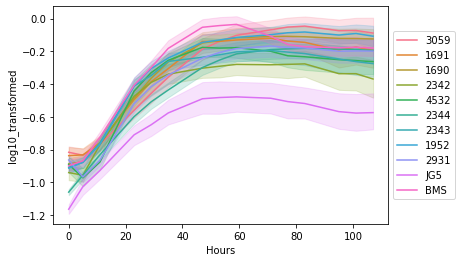

In [10]:
import seaborn as sns

plt = sns.lineplot(data = data_sorted, x = "Hours", y = "log10_transformed", hue = "Cell_Line")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

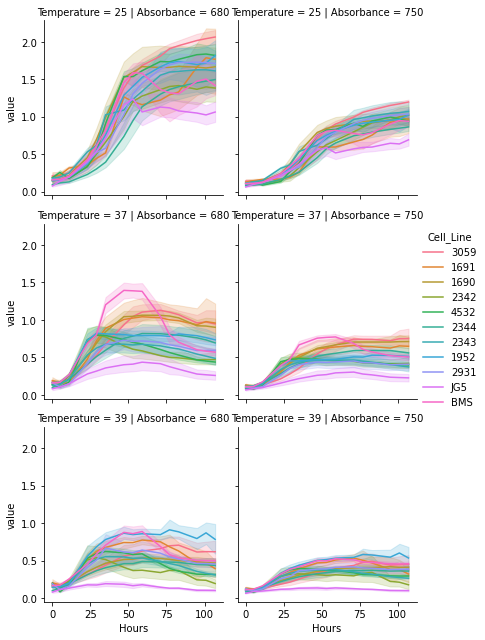

In [11]:
g = sns.FacetGrid(data_sorted, row="Temperature", col = "Absorbance", hue = "Cell_Line")
g.map(sns.lineplot,"Hours", "value")
g.add_legend()

In [12]:
data_sorted.to_csv("../../Cleaned_Data/25_39_37.csv")
data_sorted.head()

,ID,value,Hours,Absorbance,Temperature,Cell_Line,Replicate,log10_transformed
0,20230817-9AM_680_25_3059_0,1.785,71.0,680,25,3059,0,0.251638
1,20230817-9AM_680_25_3059_1,1.685,71.0,680,25,3059,1,0.226600
2,20230817-9AM_680_25_3059_2,1.862,71.0,680,25,3059,2,0.269980
3,20230817-9AM_680_25_3059_3,1.941,71.0,680,25,3059,3,0.288026
4,20230817-9AM_680_25_3059_4,1.500,71.0,680,25,3059,4,0.176091


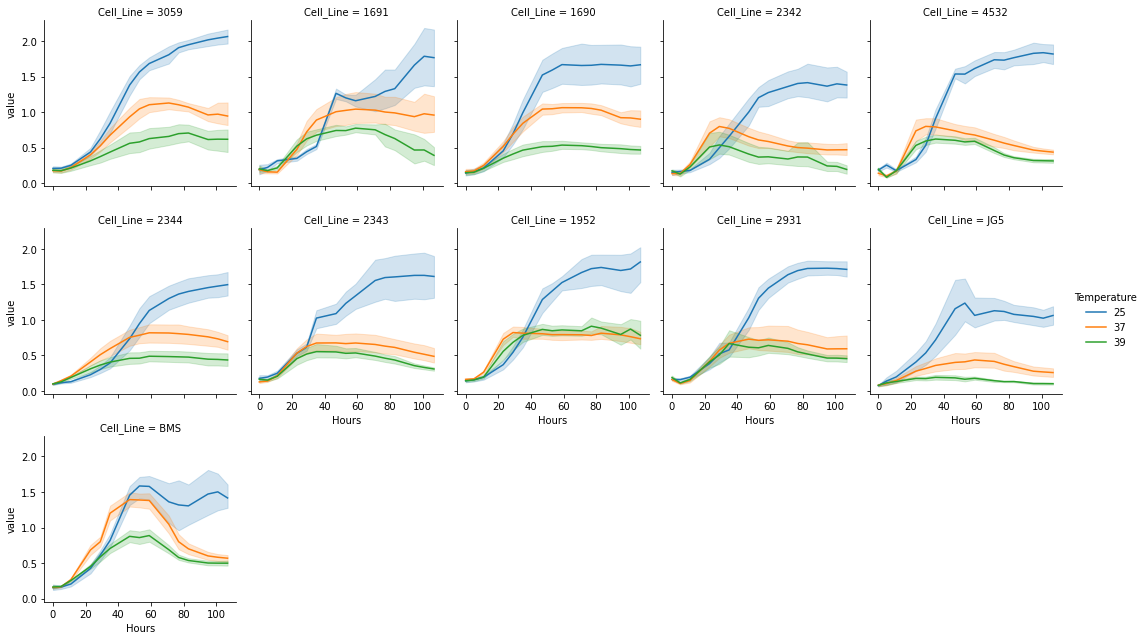

In [13]:
g = sns.FacetGrid(data_sorted[data_sorted["Absorbance"] == 680], col = "Cell_Line", col_wrap = 5, hue = "Temperature")
g.map(sns.lineplot,"Hours", "value")
g.add_legend()

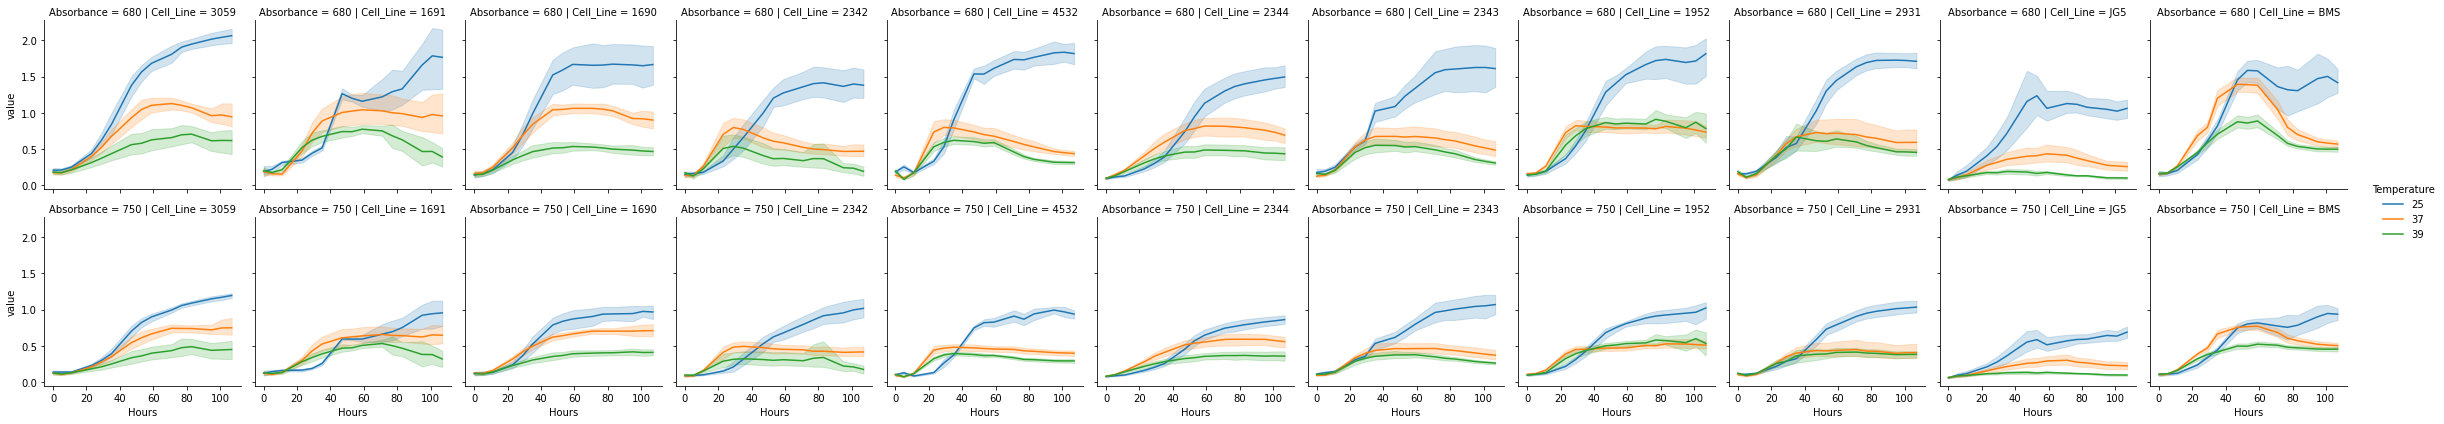

In [14]:
g = sns.FacetGrid(data_sorted, col="Cell_Line", row = "Absorbance", hue = "Temperature")
g.map(sns.lineplot,"Hours", "value")
g.add_legend()